In [1]:
from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Circle
from skimage import filters, measure, morphology
from skimage.color import label2rgb


project_root = Path.cwd()

folders = [
    "src/trackfar",
    "scripts",
    "notebooks",
    "data/raw",
    "data/results",
    "docs",
]

for folder in folders:
    (project_root / folder).mkdir(parents=True, exist_ok=True)
    
files = [
    "README.md",
    ".gitignore",
    "pyproject.toml",
    "src/trackfar/__init__.py",
    "src/trackfar/io.py",
    "scripts/inspect_video.py",
    "docs/pipeline_notes.md",
    "data/raw/.gitkeep",
    "data/results/.gitkeep",
]

for file in files:
    path = project_root / file
    path.touch(exist_ok=True)

print("Minimal project structure created at:")
print(project_root)


for path in sorted(Path.cwd().rglob("*")):
    print(path.relative_to(Path.cwd()))


In [2]:
def get_video_data(path):
    # Open the video file
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {path}")

    # Read basic video metadata
    video_info = {
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }

    # Read the first frame for testing
    ret, frame = cap.read()

    cap.release()

    if not ret:
        raise ValueError("Could not read the first frame.")

    return video_info, frame

In [6]:
def detect_cells_in_frame(
    frame,
    frame_number,
    pixel_size=1.178,
    background_sigma=50,
    closing_radius_px=2,
    min_area_px=6,
    max_area_px=120
):
    # Convert color video frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Estimate smooth illumination background
    background = filters.gaussian(
        gray_frame,
        sigma=background_sigma,
        mode="nearest",
        preserve_range=True
    )

    # Dark cells become bright after subtraction
    corrected = background - gray_frame

    # Segment cells using Otsu threshold
    threshold_value = filters.threshold_otsu(corrected)
    thresholded_img = corrected > threshold_value

    # Merge small separated parts of the same cell
    closed_mask = morphology.binary_closing(
        thresholded_img,
        morphology.disk(closing_radius_px)
    )

    # Label connected objects
    label_image = measure.label(
        closed_mask,
        connectivity=closed_mask.ndim
    )

    rows = []

    # Measure objects and keep only plausible cell sizes
    for region in measure.regionprops(label_image, intensity_image=corrected):
        area_px = region.area

        if area_px < min_area_px or area_px > max_area_px:
            continue

        rows.append({
            "frame": frame_number,
            "label": region.label,

            "y_px": region.centroid[0],
            "x_px": region.centroid[1],
            "y_um": region.centroid[0] * pixel_size,
            "x_um": region.centroid[1] * pixel_size,

            "area_px": area_px,
            "area_um2": area_px * pixel_size**2,
            "mean_intensity": region.intensity_mean,
            "threshold_value": threshold_value,

            "eccentricity_value": region.eccentricity,
            "orientation_value": region.orientation,
            "axis_major_length": region.axis_major_length,
            "axis_minor_length": region.axis_minor_length,
        })
        
        
        

    features = pd.DataFrame(rows)

    return features, corrected, thresholded_img, closed_mask, label_image

In [7]:


def plot_detection_steps(frame, corrected, thresholded_img, closed_mask, label_image):
    # Compare raw frame, correction, thresholding, closing, and label overlay
    label_overlay = label2rgb(
        label_image,
        #image=frame,
        bg_label=0,
        bg_color=(0, 0, 0)
    )

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(frame)
    axes[0].set_title("Raw frame")

    axes[1].imshow(corrected, cmap="gray")
    axes[1].set_title("Background corrected")

    axes[2].imshow(thresholded_img, cmap="gray")
    axes[2].set_title("Otsu threshold")

    axes[3].imshow(closed_mask, cmap="gray")
    axes[3].set_title("After closing")

    axes[4].imshow(label_overlay)
    axes[4].set_title("Label overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

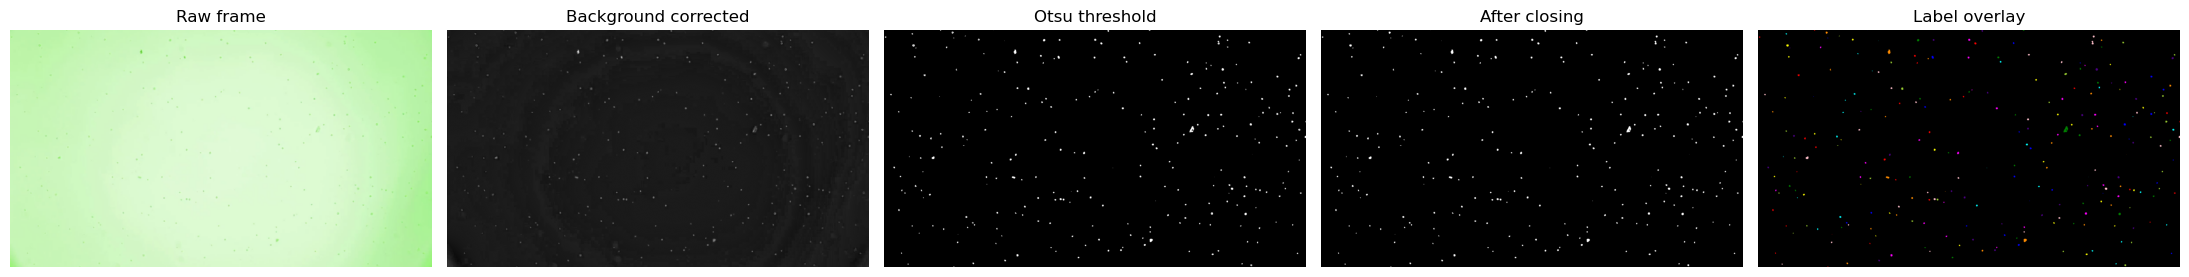

In [8]:
video_info, frame = get_video_data("../UN_test2.mp4")

features, corrected, thresholded_img, closed_mask, label_image = detect_cells_in_frame(
    frame,
    frame_number=0
)

plot_detection_steps(
    frame,
    corrected,
    thresholded_img,
    closed_mask,
    label_image
)

In [9]:
video_info

{'frame_count': 768, 'fps': 25.0, 'width': 1920, 'height': 1080}

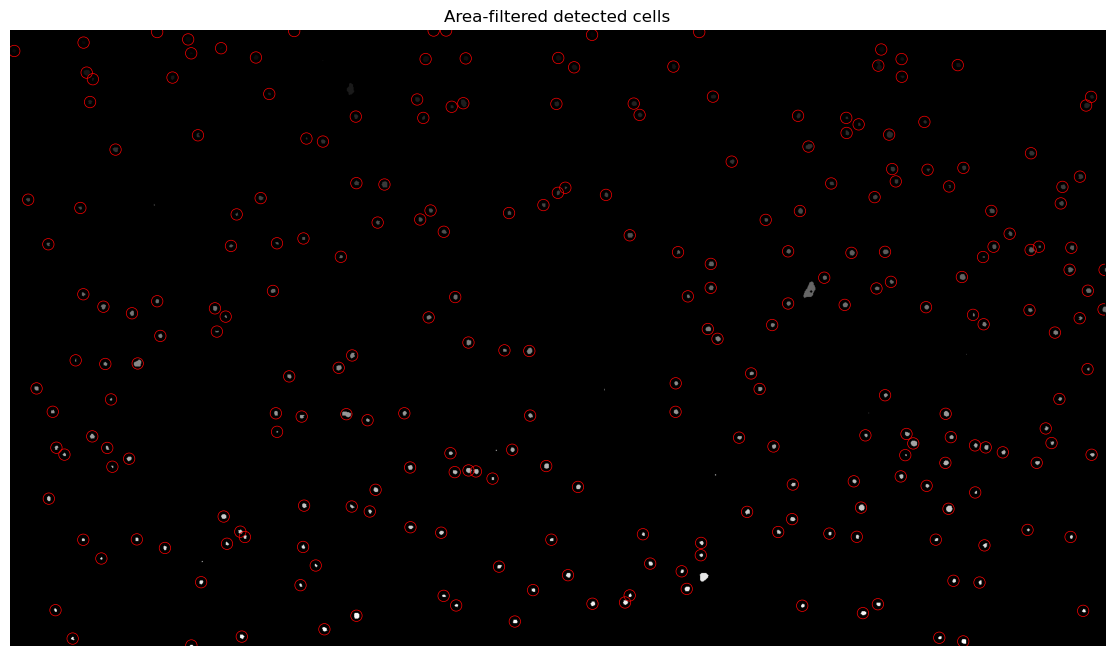

In [10]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.imshow(label_image, cmap="gray")

for _, row in features.iterrows():
    circle = Circle(
        (row["x_px"], row["y_px"]),
        radius=10,
        edgecolor="red",
        facecolor="none",
        linewidth=0.5
    )

    ax.add_patch(circle)

ax.set_title("Area-filtered detected cells")
ax.axis("off")
plt.show()

In [11]:
all_features = []

video_path = "../UN_test2.mp4"
video_info, first_frame = get_video_data(video_path)

total_frames = video_info["frame_count"]

cap = cv2.VideoCapture(video_path)
frame_number = 0

# Start timer once, before processing begins
start_time = time.time()

print("Started processing video...")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    features, corrected, thresholded_img, closed_mask, label_image = detect_cells_in_frame(
        frame,
        frame_number=frame_number
    )

    all_features.append(features)
    frame_number += 1

    if frame_number % 10 == 0:
        progress = 100 * frame_number / total_frames
        elapsed_time = time.time() - start_time

        print(
            f"Processed {progress:.1f}% "
            f"| elapsed time since start: {elapsed_time:.1f} s"
        )

cap.release()

detections = pd.concat(all_features, ignore_index=True)
# Final total time
total_time = time.time() - start_time
print(f"Finished processing in {total_time:.1f} s")

Started processing video...
Processed 1.3% | elapsed time since start: 8.7 s
Processed 2.6% | elapsed time since start: 17.4 s
Processed 3.9% | elapsed time since start: 26.0 s
Processed 5.2% | elapsed time since start: 34.7 s
Processed 6.5% | elapsed time since start: 43.4 s
Processed 7.8% | elapsed time since start: 52.2 s
Processed 9.1% | elapsed time since start: 61.1 s
Processed 10.4% | elapsed time since start: 69.9 s
Processed 11.7% | elapsed time since start: 78.7 s
Processed 13.0% | elapsed time since start: 87.6 s
Processed 14.3% | elapsed time since start: 96.5 s
Processed 15.6% | elapsed time since start: 105.4 s
Processed 16.9% | elapsed time since start: 114.3 s
Processed 18.2% | elapsed time since start: 123.2 s
Processed 19.5% | elapsed time since start: 132.1 s
Processed 20.8% | elapsed time since start: 141.0 s
Processed 22.1% | elapsed time since start: 149.9 s
Processed 23.4% | elapsed time since start: 158.8 s
Processed 24.7% | elapsed time since start: 167.6 s
Pro

In [12]:
cell_label = row["label"]
cell_mask = label_image == cell_label

In [13]:

def plot_sample_cell_orientations(features, label_image, n_cells=10, margin=10):
    # Randomly choose accepted detected cells
    sample_features = features.sample(
        n=n_cells,
        random_state=0
    )

    # Get region information from the labeled image
    regions = measure.regionprops(label_image)
    regions_by_label = {region.label: region for region in regions}

    fig, axes = plt.subplots(1, n_cells, figsize=(4 * n_cells, 4))

    for ax, (_, row) in zip(axes, sample_features.iterrows()):
        region = regions_by_label[row["label"]]

        # Bounding box of the selected object
        min_row, min_col, max_row, max_col = region.bbox

        # Add margin around the ROI
        roi_min_row = max(min_row - margin, 0)
        roi_min_col = max(min_col - margin, 0)
        roi_max_row = min(max_row + margin, label_image.shape[0])
        roi_max_col = min(max_col + margin, label_image.shape[1])

        # Keep only the selected object inside the ROI
        cell_mask = label_image == region.label

        roi = cell_mask[
            roi_min_row:roi_max_row,
            roi_min_col:roi_max_col
        ]

        # Centroid in full-image coordinates
        y0, x0 = region.centroid

        # Centroid shifted into ROI coordinates
        y0_roi = y0 - roi_min_row
        x0_roi = x0 - roi_min_col

        orientation = region.orientation

        # Minor axis endpoint
        x_minor = x0_roi + math.cos(orientation) * 0.5 * region.axis_minor_length
        y_minor = y0_roi - math.sin(orientation) * 0.5 * region.axis_minor_length

        # Major axis endpoint
        x_major = x0_roi - math.sin(orientation) * 0.5 * region.axis_major_length
        y_major = y0_roi - math.cos(orientation) * 0.5 * region.axis_major_length

        ax.imshow(roi, cmap="gray")

        # Plot orientation axes and centroid
        ax.plot((x0_roi, x_minor), (y0_roi, y_minor), "-r", linewidth=2)
        ax.plot((x0_roi, x_major), (y0_roi, y_major), "-r", linewidth=2)
        ax.plot(x0_roi, y0_roi, ".g", markersize=10)

        ax.set_title(f"Cell label {int(row['label'])}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

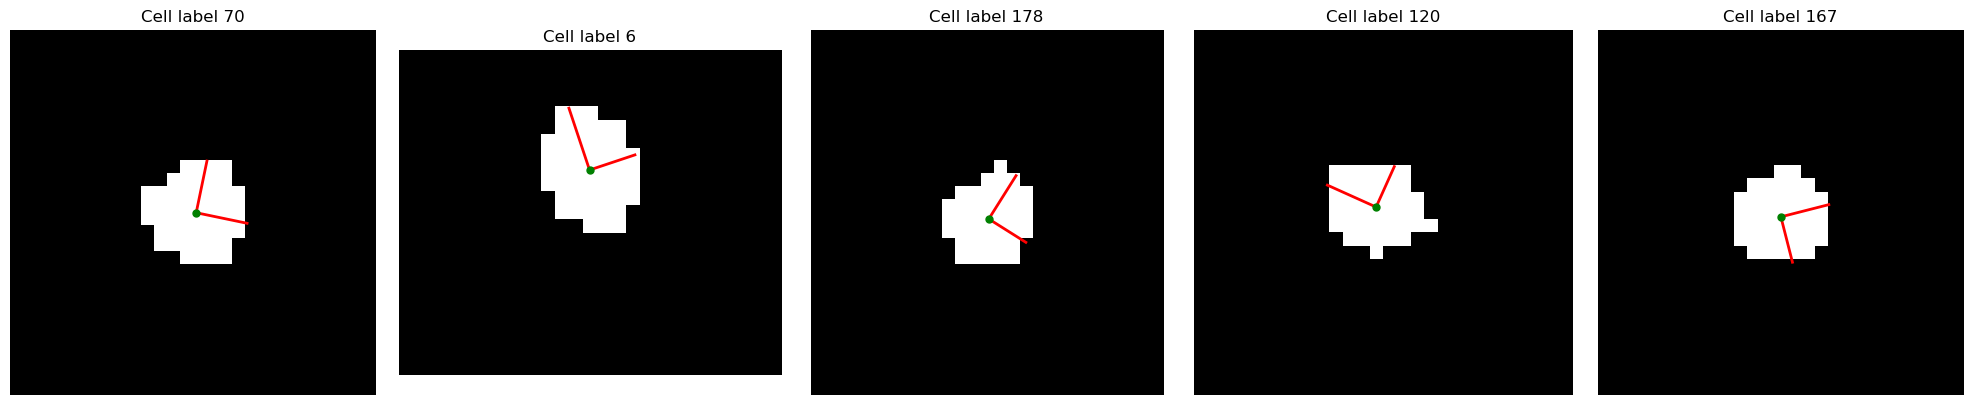

In [14]:
features, corrected, thresholded_img, closed_mask, label_image = detect_cells_in_frame(
    first_frame,
    frame_number=86
)

sample_features = features.sample(n=5)

plot_sample_cell_orientations(
    sample_features,
    label_image,
    n_cells=5
)

# Linking

Linking
→ create tracks

Find jumps
→ create selected_jmp_links

Merge tracks
→ create tracks_merged

Validate
→ check velocity, VAC, plots

In [15]:
# 1. Initialize frame-to-frame linking

# Goal: create initial track IDs and prepare for frame-to-frame linking.

from scipy.spatial import cKDTree

# -----------------------------
# 1. Define tracking parameters
# -----------------------------

fps = 25
v_cell = 100  # expected cell speed in um/s

# Maximum allowed displacement between two consecutive frames.
# 5.2 um/frame corresponds to 130 um/s at 25 fps.
max_distance_um = 5.6

# Weight for velocity autocorrelation.
# Distance is still the main criterion; VAC only gives a small bonus
# to candidates that continue in the same direction.
vac_weight_um = 0.25


# ---------------------------------------------
# 2. Create a working copy of the detections table
# ---------------------------------------------

# tracked_detections keeps all original detection information,
# plus one new column: track_id.
tracked_detections = detections.copy()
tracked_detections["track_id"] = np.nan


# ------------------------------------------------
# 3. Initialize storage for active track histories
# ------------------------------------------------

# track_history stores the list of detection indices belonging to each track.
# Example:
# track_history[5] = [120, 185, 240]
# means track 5 contains those detection rows.
track_history = {}

# next_track_id is increased every time a new track is created.
next_track_id = 0


# ------------------------------------
# 4. Get all frame numbers in time order
# ------------------------------------

frame_numbers = sorted(detections["frame"].unique())


# ------------------------------------------------
# 5. Start one track for each detection in frame 0
# ------------------------------------------------

first_frame_number = frame_numbers[0]
first_frame = detections[detections["frame"] == first_frame_number]

for detection_index in first_frame.index:
    tracked_detections.loc[detection_index, "track_id"] = next_track_id
    track_history[next_track_id] = [detection_index]
    next_track_id += 1

In [16]:
# 2. Define velocity autocorrelation function
# Goal: measure whether motion keeps the same direction.

def calculate_vac(p0, p1, p2):
    """
    Calculate velocity autocorrelation (VAC) from three positions.

    p0: previous position of the same track
    p1: current/last position of the same track
    p2: candidate next position

    VAC close to  1 means the cell keeps moving in the same direction.
    VAC close to  0 means the direction is unrelated/perpendicular.
    VAC close to -1 means the cell reverses direction.
    """

    # Movement vector from p0 to p1
    v1 = p1 - p0

    # Movement vector from p1 to p2
    v2 = p2 - p1

    # Normalize so VAC measures direction only, not speed.
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)

    # If one movement vector has zero length, direction is undefined.
    if denominator == 0:
        return np.nan

    # Cosine similarity between the two movement vectors.
    return np.dot(v1, v2) / denominator

# For each frame
→ find possible links from previous-frame active tracks
→ score links by distance and VAC
→ accept best non-conflicting links
→ start new tracks for unmatched detections

In [17]:
# 3. Link detections frame by frame
# Goal: assign each detection to a track using distance and direction consistency.
# This cell only links: frame t → frame t+1
all_links = []

# Start from the second frame because the first frame was already initialized.
for frame_number in frame_numbers[1:]:

    # Detections observed in the current frame.
    current_frame = detections[detections["frame"] == frame_number]

    # This list will store all possible links into the current frame.
    candidate_links = []

    # Positions and row indices of current-frame detections.
    current_positions = current_frame[["x_um", "y_um"]].to_numpy()
    current_indices = current_frame.index.to_numpy()

    # If the current frame has no detections, no linking is possible.
    if len(current_frame) == 0:
        continue

    # Build a spatial search tree for fast nearest-neighbor queries.
    # This avoids comparing every track with every detection.
    current_tree = cKDTree(current_positions)

    # Try to extend each active track into the current frame.
    for track_id, history in track_history.items():

        # Last detection currently assigned to this track.
        last_detection = history[-1]
        last_frame = tracked_detections.loc[last_detection, "frame"]

        # Only tracks ending in the immediately previous frame are linked here.
        # Tracks with gaps are handled later by the jump-detection step.
        if last_frame != frame_number - 1:
            continue

        # Last known position of this track.
        p1 = tracked_detections.loc[
            last_detection,
            ["x_um", "y_um"]
        ].to_numpy()

        # Find current-frame detections within the allowed distance.
        nearby_candidate_positions = current_tree.query_ball_point(
            p1,
            r=max_distance_um
        )

        # Build candidate links from this track to nearby detections.
        for candidate_position in nearby_candidate_positions:
            candidate_detection = current_indices[candidate_position]
            p2 = current_positions[candidate_position]

            # Distance from the track endpoint to the candidate detection.
            distance_um = np.linalg.norm(p2 - p1)

            # VAC needs two previous points from the same track.
            # For the first link of a track, direction is not defined yet.
            if len(history) < 2:
                vac = np.nan
            else:
                previous_detection = history[-2]
                p0 = tracked_detections.loc[
                    previous_detection,
                    ["x_um", "y_um"]
                ].to_numpy()

                vac = calculate_vac(p0, p1, p2)

            candidate_links.append({
                "track_id": track_id,
                "detection_a": last_detection,
                "detection_b": candidate_detection,
                "frame_a": frame_number - 1,
                "frame_b": frame_number,
                "distance_um": distance_um,
                "vac": vac,
            })

    # Score candidate links.
    # Lower score is better.
    # Distance is the main cost.
    # Positive VAC reduces the score slightly, favoring smooth motion.
    for link in candidate_links:
        if np.isnan(link["vac"]):
            link["score"] = link["distance_um"]
        else:
            link["score"] = link["distance_um"] - vac_weight_um * link["vac"]

    candidate_links = sorted(
        candidate_links,
        key=lambda link: link["score"]
    )

    # These sets prevent conflicts:
    # one track can link to only one detection,
    # and one detection can be assigned to only one track.
    assigned_tracks = set()
    assigned_detections = set()

    # Accept the best non-conflicting candidate links.
    for link in candidate_links:
        track_id = link["track_id"]
        detection_b = link["detection_b"]

        if track_id in assigned_tracks:
            continue

        if detection_b in assigned_detections:
            continue

        # Assign the current detection to the existing track.
        tracked_detections.loc[detection_b, "track_id"] = track_id

        # Update the history of this track.
        track_history[track_id].append(detection_b)

        assigned_tracks.add(track_id)
        assigned_detections.add(detection_b)

        # Store the accepted link for diagnostics.
        all_links.append(link)

    # Any current-frame detection that was not linked starts a new track.
    for detection_index in current_frame.index:
        if detection_index not in assigned_detections:
            tracked_detections.loc[detection_index, "track_id"] = next_track_id
            track_history[next_track_id] = [detection_index]
            next_track_id += 1

In [18]:
# 4. Create final link and initial track tables
# Goal: save the result of frame-to-frame linking in clean tables.

# links stores only the accepted connections between detections.
# Each row is one accepted link from frame t to frame t+1.
links = pd.DataFrame(all_links)

# tracks stores all detections that received a track_id.
# This is the first version of the trajectories before jump merging.
tracks = tracked_detections.dropna(subset=["track_id"]).copy()
tracks["track_id"] = tracks["track_id"].astype(int)

# Sort tracks by ID and time so later calculations are correct.
tracks = tracks.sort_values(["track_id", "frame"]).copy()

<div style="
border-left:6px solid #2F75B5;
background-color:#F4F8FC;
padding:10px;
margin:10px 0;
">

<b>Step 4. Build preliminary tracks and validate link quality</b>

<ul>
<li>Construct an initial track table from the accepted frame-to-frame links.</li>
<li>Compute Δx, Δy, and Δt for each link.</li>
<li>Calculate the corresponding instantaneous speed.</li>
<li>Verify that the resulting speeds are biologically plausible and consistent with expected cell motility.</li>
</ul>



<div style="color:blue; font-weight:bold; font-size:16px;">
⚠This is a diagnostic step only and is not used for track assignment. The actual linking was performed in the previous cell.
</div>


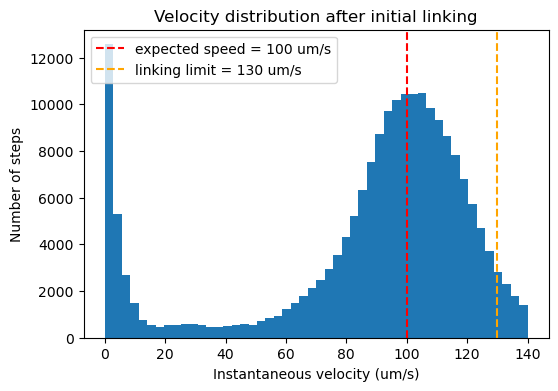

Instantaneous velocity summary, um/s:
count    196055.000000
mean         86.992467
std          36.832644
min           0.000000
25%          79.196947
50%          97.498690
75%         110.977841
max         139.999533
Name: instant_velocity_um_s, dtype: float64

Velocity percentiles, um/s:
0.50     97.498690
0.75    110.977841
0.90    121.653067
0.95    127.581425
0.99    136.150581
Name: instant_velocity_um_s, dtype: float64

Equivalent displacement per frame, um/frame:
0.50    3.899948
0.75    4.439114
0.90    4.866123
0.95    5.103257
0.99    5.446023
Name: instant_velocity_um_s, dtype: float64


In [19]:
# Use the initial tracks table created in the previous cell.
# Make a diagnostic copy so velocity columns do not modify the clean tracks table.
tracks_velocity_check = tracks.copy()

# Sort by track and time before calculating step sizes.
tracks_velocity_check = tracks_velocity_check.sort_values(["track_id", "frame"]).copy()


# ---------------------------------------------------
# Calculate displacement and instantaneous velocity
# ---------------------------------------------------

# Difference in position between consecutive detections in the same track.
tracks_velocity_check["dx_um"] = tracks_velocity_check.groupby("track_id")["x_um"].diff()
tracks_velocity_check["dy_um"] = tracks_velocity_check.groupby("track_id")["y_um"].diff()

# Difference in frame number between consecutive detections.
tracks_velocity_check["dt_frame"] = tracks_velocity_check.groupby("track_id")["frame"].diff()

# Step distance in micrometers.
tracks_velocity_check["step_distance_um"] = np.sqrt(
    tracks_velocity_check["dx_um"]**2
    + tracks_velocity_check["dy_um"]**2
)

# Convert frame difference to seconds.
tracks_velocity_check["dt_s"] = tracks_velocity_check["dt_frame"] / fps

# Instantaneous velocity in um/s.
tracks_velocity_check["instant_velocity_um_s"] = (
    tracks_velocity_check["step_distance_um"] / tracks_velocity_check["dt_s"]
)


# ---------------------------------------------------
# Keep only normal frame-to-frame steps for this check
# ---------------------------------------------------

# At this stage, the linker only connects frame t to frame t+1.
# We still filter dt_frame == 1 explicitly to avoid accidental mixed cases.
valid_steps = tracks_velocity_check[
    (tracks_velocity_check["dt_frame"] == 1)
    & tracks_velocity_check["instant_velocity_um_s"].notna()
].copy()


# ---------------------------------------------------
# Plot velocity distribution
# ---------------------------------------------------

plt.figure(figsize=(6, 4))
plt.hist(valid_steps["instant_velocity_um_s"], bins=50)
plt.axvline(100, color="red", linestyle="--", label="expected speed = 100 um/s")
plt.axvline(130, color="orange", linestyle="--", label="linking limit = 130 um/s")
plt.xlabel("Instantaneous velocity (um/s)")
plt.ylabel("Number of steps")
plt.title("Velocity distribution after initial linking")
plt.legend()
plt.show()


# ---------------------------------------------------
# Numerical summary
# ---------------------------------------------------

print("Instantaneous velocity summary, um/s:")
print(valid_steps["instant_velocity_um_s"].describe())

velocity_percentiles = valid_steps["instant_velocity_um_s"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

print("\nVelocity percentiles, um/s:")
print(velocity_percentiles)

# Convert velocity percentiles to displacement per frame.
distance_percentiles = velocity_percentiles / fps

print("\nEquivalent displacement per frame, um/frame:")
print(distance_percentiles)

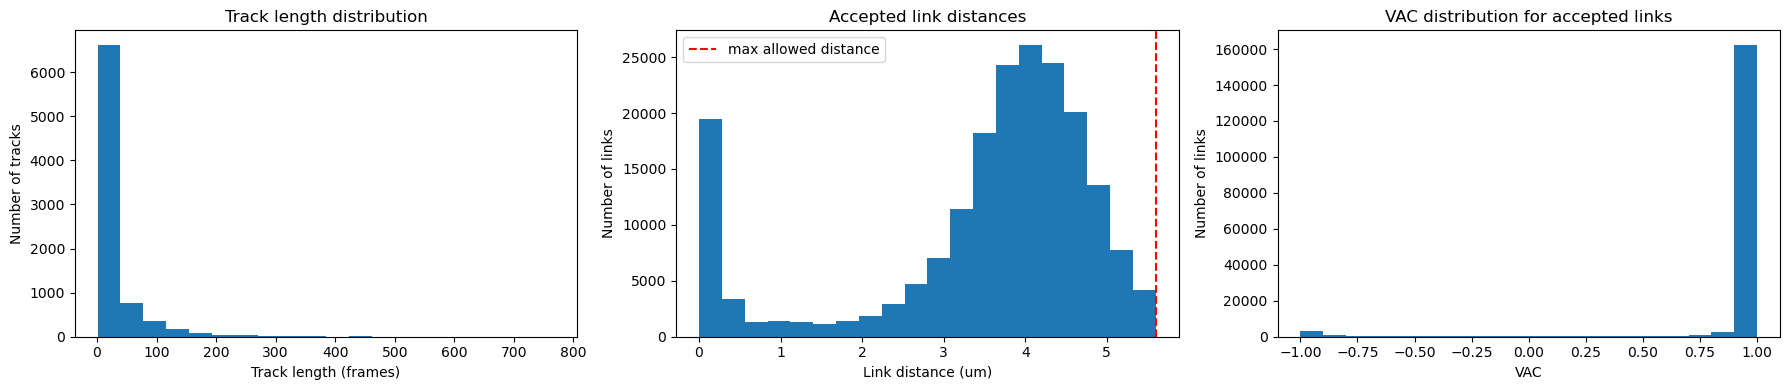

count                            8127.000000
mean                               25.123908
std                                49.404176
min                                 1.000000
25%                                 2.000000
50%                                 5.000000
75%                                26.000000
max                               768.000000
Tracks longer than 50 frames     1235.000000
Tracks longer than 100 frames     521.000000
Tracks longer than 200 frames     124.000000
dtype: float64

In [20]:
# 5. Diagnose initial linking quality
# Goal: summarize track lengths, accepted link distances, and VAC values.

# Count how many detections/frames belong to each initial track.
track_lengths = tracks.groupby("track_id").size()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))


# ---------------------------------------------------
# 1. Track length distribution
# ---------------------------------------------------

# Long tracks suggest stable linking.
# Many very short tracks suggest fragmentation or missed detections.
axes[0].hist(track_lengths, bins=20)
axes[0].set_xlabel("Track length (frames)")
axes[0].set_ylabel("Number of tracks")
axes[0].set_title("Track length distribution")


# ---------------------------------------------------
# 2. Accepted link distances
# ---------------------------------------------------

# This shows how close accepted links are to the maximum allowed distance.
# If many links pile up near max_distance_um, the threshold is strongly limiting.
axes[1].hist(links["distance_um"], bins=20)
axes[1].axvline(
    max_distance_um,
    color="red",
    linestyle="--",
    label="max allowed distance"
)
axes[1].set_xlabel("Link distance (um)")
axes[1].set_ylabel("Number of links")
axes[1].set_title("Accepted link distances")
axes[1].legend()


# ---------------------------------------------------
# 3. VAC distribution
# ---------------------------------------------------

# VAC close to 1 means the accepted links preserve direction.
# VAC close to 0 means direction is weakly related.
# VAC close to -1 means direction reverses.
axes[2].hist(links["vac"].dropna(), bins=20)
axes[2].set_xlabel("VAC")
axes[2].set_ylabel("Number of links")
axes[2].set_title("VAC distribution for accepted links")

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Numerical summary of initial track lengths
# ---------------------------------------------------

summary = pd.concat([
    track_lengths.describe(),
    pd.Series({
        "Tracks longer than 50 frames": (track_lengths >= 50).sum(),
        "Tracks longer than 100 frames": (track_lengths >= 100).sum(),
        "Tracks longer than 200 frames": (track_lengths >= 200).sum(),
    })
])

summary

Number of initial tracks: 8127
Longest initial track length: 768
Shortest track in this plot: 162


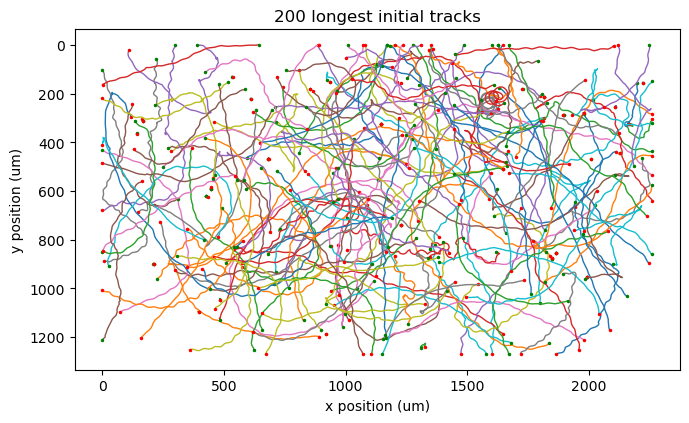

In [21]:
# 6. Plot the longest initial tracks
# Goal: visually inspect whether the first linked tracks look continuous and reasonable.

n_tracks_to_plot = 200

# Count how many detections belong to each track.
track_lengths = tracks.groupby("track_id").size()

# Select the longest tracks because they are most informative for visual inspection.
selected_track_ids = track_lengths.nlargest(n_tracks_to_plot).index

print("Number of initial tracks:", tracks["track_id"].nunique())
print("Longest initial track length:", track_lengths.max())
print("Shortest track in this plot:", track_lengths.loc[selected_track_ids].min())


plt.figure(figsize=(7, 7))

for track_id in selected_track_ids:

    # Extract one track and sort it by time.
    track = tracks[
        tracks["track_id"] == track_id
    ].sort_values("frame")

    # Plot the full trajectory.
    plt.plot(
        track["x_um"],
        track["y_um"],
        "-",
        linewidth=1
    )

    # Mark the start point in green.
    plt.plot(
        track["x_um"].iloc[0],
        track["y_um"].iloc[0],
        "go",
        markersize=1.5
    )

    # Mark the end point in red.
    plt.plot(
        track["x_um"].iloc[-1],
        track["y_um"].iloc[-1],
        "ro",
        markersize=1.5
    )

plt.xlabel("x position (um)")
plt.ylabel("y position (um)")
plt.title(f"{n_tracks_to_plot} longest initial tracks")

# Keep real spatial proportions.
plt.gca().set_aspect("equal")

# Invert y-axis to match image-coordinate convention.
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Jump Detection for Broken Tracks

<div style="
border-left:6px solid #2F75B5;
background-color:#F4F8FC;
padding:10px;
margin:10px 0;
">

<b>Data tables</b>

<ul>
<li><b>tracks</b>: one row per detection.</li>
<li><b>track_summary</b>: one row per track, including start frame, end frame, start position, end position, and track length.</li>
</ul>
This is needed because jump detection asks:Can the end of track A plausibly continue into the start of track B?
</div>

In [22]:
# 7. Summarize initial tracks for jump detection
# Goal: describe the start and end point of each track segment.

# Jump detection works at the track-segment level, not at the detection level.
# For each track, we store when and where it starts and ends.

track_summary = []

for track_id, track in tracks.groupby("track_id"):

    # Sort each track by time to correctly identify start and end points.
    track = track.sort_values("frame")

    track_summary.append({
        "track_id": track_id,

        # First and last frame of this track segment.
        "start_frame": track["frame"].iloc[0],
        "end_frame": track["frame"].iloc[-1],

        # First position of this track segment.
        "start_x_um": track["x_um"].iloc[0],
        "start_y_um": track["y_um"].iloc[0],

        # Last position of this track segment.
        "end_x_um": track["x_um"].iloc[-1],
        "end_y_um": track["y_um"].iloc[-1],

        # Number of detections in this track segment.
        "length": len(track),
    })

track_summary = pd.DataFrame(track_summary)

<div style="
border-left:6px solid #2F75B5;
background-color:#F4F8FC;
padding:10px;
margin:10px 0;
">

<b>Gap-closing criteria</b>

<ul>
<li>Short time gap between segments.</li>
<li>Reasonable spatial distance between segment endpoints.</li>
<li>Biologically plausible linking speed.</li>
<li>Minimum segment length requirement for both segments.</li>
</ul>

</div>

In [23]:
# 8. Find candidate jumps between broken track segments
# Goal: find pairs where track B may be a continuation of track A.

# Maximum number of missing frames allowed between two track segments.
max_jmp_frames = 4

# Maximum biologically plausible jump speed.
max_jmp_speed_um_s = 140

# Minimum segment length required before considering a track for merging.
# This avoids merging very short/noisy fragments.
min_segment_length = 20


jmp_candidates = []

# Compare every possible pair of track segments:
# end_track = earlier segment
# start_track = possible later continuation
for _, end_track in track_summary.iterrows():
    for _, start_track in track_summary.iterrows():

        # A track cannot be merged with itself.
        if end_track["track_id"] == start_track["track_id"]:
            continue

        # Number of frames between the end of A and the start of B.
        jmp_frames = start_track["start_frame"] - end_track["end_frame"]

        # B must start after A ends.
        if jmp_frames <= 0:
            continue

        # Only allow short gaps.
        if jmp_frames > max_jmp_frames:
            continue

        # Require both segments to be long enough for reliable merging.
        if end_track["length"] < min_segment_length:
            continue

        if start_track["length"] < min_segment_length:
            continue

        # Endpoint of the earlier track and start point of the later track.
        p_end = np.array([end_track["end_x_um"], end_track["end_y_um"]])
        p_start = np.array([start_track["start_x_um"], start_track["start_y_um"]])

        # Spatial gap between the two track segments.
        distance_um = np.linalg.norm(p_start - p_end)

        # Allowed jump distance depends on the number of missing frames.
        allowed_distance_um = max_jmp_speed_um_s * jmp_frames / fps

        if distance_um > allowed_distance_um:
            continue

        # Equivalent jump speed.
        speed_um_s = distance_um / jmp_frames * fps

        jmp_candidates.append({
            "track_a": end_track["track_id"],
            "track_b": start_track["track_id"],
            "jmp_frames": jmp_frames,
            "distance_um": distance_um,
            "allowed_distance_um": allowed_distance_um,
            "speed_um_s": speed_um_s,
            "length_a": end_track["length"],
            "length_b": start_track["length"],
        })

In [24]:
# 9. Convert jump candidates to a table

jmp_candidates = pd.DataFrame(jmp_candidates)

print("Number of candidate jumps:", len(jmp_candidates))

if len(jmp_candidates) > 0:
    display(
        jmp_candidates.sort_values(
            ["jmp_frames", "speed_um_s", "distance_um"]
        ).head(20)
    )

Number of candidate jumps: 598


,track_a,track_b,jmp_frames,distance_um,allowed_distance_um,speed_um_s,length_a,length_b
341,3798.0,4427.0,2.0,0.000000,11.2,0.000000,60.0,90.0
370,4129.0,6155.0,2.0,0.133546,11.2,1.669320,181.0,45.0
396,4427.0,5471.0,2.0,0.190486,11.2,2.381081,90.0,64.0
10,61.0,1898.0,2.0,0.210234,11.2,2.627923,178.0,51.0
85,679.0,1574.0,2.0,0.211175,11.2,2.639684,94.0,259.0
496,5842.0,6069.0,2.0,0.323801,11.2,4.047515,21.0,154.0
472,5461.0,6985.0,2.0,0.392667,11.2,4.908333,151.0,27.0
263,2767.0,3223.0,2.0,0.439015,11.2,5.487683,40.0,35.0
222,2370.0,2878.0,2.0,0.465645,11.2,5.820567,46.0,31.0
7,25.0,4705.0,2.0,0.577026,11.2,7.212823,451.0,88.0


In [25]:
# 10. Calculate VAC for candidate jumps
# Goal: check whether the jump continues the direction of track A.

jmp_candidates_with_vac = []

for _, candidate in jmp_candidates.iterrows():

    # Earlier segment.
    track_a = tracks[
        tracks["track_id"] == candidate["track_a"]
    ].sort_values("frame")

    # Possible later continuation.
    track_b = tracks[
        tracks["track_id"] == candidate["track_b"]
    ].sort_values("frame")

    # Need at least two points in track A to estimate its final direction.
    if len(track_a) < 2:
        continue

    # p0 -> p1 is the final movement direction of track A.
    p0 = track_a[["x_um", "y_um"]].iloc[-2].to_numpy()
    p1 = track_a[["x_um", "y_um"]].iloc[-1].to_numpy()

    # p1 -> p2 is the proposed jump from A to B.
    p2 = track_b[["x_um", "y_um"]].iloc[0].to_numpy()

    # jmp_vac measures whether the proposed jump follows the same direction.
    jmp_vac = calculate_vac(p0, p1, p2)

    row = candidate.to_dict()
    row["jmp_vac"] = jmp_vac

    jmp_candidates_with_vac.append(row)

jmp_candidates_with_vac = pd.DataFrame(jmp_candidates_with_vac)

print("Candidate jumps before VAC:", len(jmp_candidates))
print("Candidate jumps with VAC:", len(jmp_candidates_with_vac))

if len(jmp_candidates_with_vac) > 0:
    display(
        jmp_candidates_with_vac.sort_values(
            ["jmp_vac", "speed_um_s"],
            ascending=[False, True]
        ).head(20)
    )

Candidate jumps before VAC: 598
Candidate jumps with VAC: 598


,track_a,track_b,jmp_frames,distance_um,allowed_distance_um,speed_um_s,length_a,length_b,jmp_vac
257,2730.0,4716.0,4.0,15.904135,22.4,99.400845,191.0,142.0,1.000000
576,6939.0,7825.0,3.0,15.538874,16.8,129.490615,77.0,21.0,1.000000
492,5807.0,6265.0,3.0,15.188866,16.8,126.573880,41.0,22.0,0.999999
195,2066.0,2547.0,4.0,20.566859,22.4,128.542867,42.0,41.0,0.999998
339,3791.0,4265.0,4.0,15.540331,22.4,97.127068,41.0,67.0,0.999998
453,5176.0,6306.0,3.0,13.541137,16.8,112.842810,96.0,20.0,0.999997
4,18.0,742.0,3.0,12.235478,16.8,101.962319,59.0,21.0,0.999997
251,2655.0,2920.0,3.0,12.429096,16.8,103.575796,23.0,122.0,0.999994
361,4007.0,4251.0,4.0,19.639577,22.4,122.747356,21.0,23.0,0.999986
163,1485.0,3001.0,3.0,13.017067,16.8,108.475555,140.0,105.0,0.999978


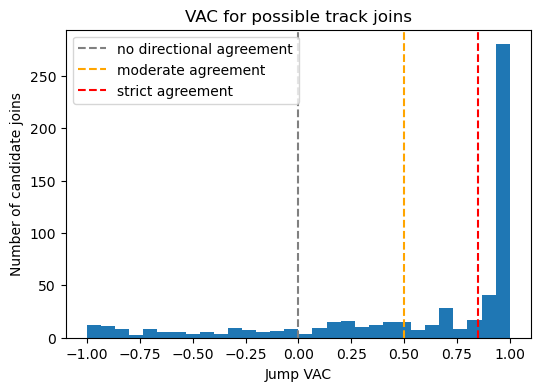

In [26]:
# 11. Plot VAC distribution for candidate jumps
# Goal: choose a reasonable VAC threshold for broken-track merging.

plt.figure(figsize=(6, 4))

plt.hist(
    jmp_candidates_with_vac["jmp_vac"].dropna(),
    bins=30
)

# Reference lines for interpretation.
plt.axvline(0, color="gray", linestyle="--", label="no directional agreement")
plt.axvline(0.5, color="orange", linestyle="--", label="moderate agreement")
plt.axvline(0.85, color="red", linestyle="--", label="strict agreement")

plt.xlabel("Jump VAC")
plt.ylabel("Number of candidate joins")
plt.title("VAC for possible track joins")
plt.legend()
plt.show()

In [27]:
# 12. Define final thresholds for selecting jump links
# Goal: choose high-confidence broken-track joins.

# Maximum gap duration allowed between two track segments.
max_jmp_frames = 4

# Maximum biologically plausible jump speed.
max_jmp_speed_um_s = 140

# Minimum VAC required for directional consistency.
# 0.85 is strict: it keeps only jumps that strongly continue the previous direction.
min_jmp_vac = 0.85

# Minimum length required for both track segments.
# This avoids merging very short/noisy fragments.
min_segment_length = 20

In [28]:
# 13. Select high-confidence jump links
# Goal: keep only plausible and non-conflicting broken-track joins.

# Filter candidate jumps using speed, gap size, direction, and segment length.
strong_jmp_candidates = jmp_candidates_with_vac[
    (jmp_candidates_with_vac["jmp_frames"] <= max_jmp_frames)
    & (jmp_candidates_with_vac["speed_um_s"] <= max_jmp_speed_um_s)
    & (jmp_candidates_with_vac["jmp_vac"] >= min_jmp_vac)
    & (jmp_candidates_with_vac["length_a"] >= min_segment_length)
    & (jmp_candidates_with_vac["length_b"] >= min_segment_length)
].copy()

# Sort so the most conservative joins are considered first:
# shorter gaps, lower speeds, higher directional consistency.
strong_jmp_candidates = strong_jmp_candidates.sort_values(
    ["jmp_frames", "speed_um_s", "jmp_vac"],
    ascending=[True, True, False]
)

print("Strong jump candidates:", len(strong_jmp_candidates))

if len(strong_jmp_candidates) > 0:
    display(strong_jmp_candidates.head(20))


# ---------------------------------------------------
# Resolve conflicts between candidate joins
# ---------------------------------------------------

# selected_jmp_links will contain the final accepted jump links.
selected_jmp_links = []

# A track ending can be connected to only one later track.
used_end_tracks = set()

# A track start can receive only one earlier track.
used_start_tracks = set()

for _, row in strong_jmp_candidates.iterrows():

    track_a = int(row["track_a"])  # earlier track segment
    track_b = int(row["track_b"])  # later track segment

    # If track A already continues into another track, skip this candidate.
    if track_a in used_end_tracks:
        continue

    # If track B is already assigned as a continuation, skip this candidate.
    if track_b in used_start_tracks:
        continue

    # Accept this non-conflicting jump link.
    selected_jmp_links.append(row)

    used_end_tracks.add(track_a)
    used_start_tracks.add(track_b)

selected_jmp_links = pd.DataFrame(selected_jmp_links)

print("Selected jump links:", len(selected_jmp_links))

if len(selected_jmp_links) > 0:
    display(selected_jmp_links.head(20))

Strong jump candidates: 326


,track_a,track_b,jmp_frames,distance_um,allowed_distance_um,speed_um_s,length_a,length_b,jmp_vac
370,4129.0,6155.0,2.0,0.133546,11.2,1.669320,181.0,45.0,0.923862
242,2601.0,2984.0,2.0,2.286732,11.2,28.584149,35.0,134.0,0.972655
329,3626.0,3886.0,2.0,4.008621,11.2,50.107766,26.0,329.0,0.892575
475,5572.0,7022.0,2.0,5.088284,11.2,63.603546,145.0,98.0,0.906315
435,4857.0,5272.0,2.0,5.789927,11.2,72.374092,33.0,267.0,0.998188
40,149.0,563.0,2.0,6.263533,11.2,78.294164,39.0,48.0,0.998550
580,7011.0,7635.0,2.0,6.296729,11.2,78.709115,54.0,44.0,0.969188
390,4393.0,4703.0,2.0,6.314002,11.2,78.925023,30.0,48.0,0.913384
393,4409.0,5271.0,2.0,6.473462,11.2,80.918276,77.0,26.0,0.994516
550,6448.0,6639.0,2.0,6.578766,11.2,82.234578,24.0,84.0,0.909735


Selected jump links: 301


,track_a,track_b,jmp_frames,distance_um,allowed_distance_um,speed_um_s,length_a,length_b,jmp_vac
370,4129.0,6155.0,2.0,0.133546,11.2,1.669320,181.0,45.0,0.923862
242,2601.0,2984.0,2.0,2.286732,11.2,28.584149,35.0,134.0,0.972655
329,3626.0,3886.0,2.0,4.008621,11.2,50.107766,26.0,329.0,0.892575
475,5572.0,7022.0,2.0,5.088284,11.2,63.603546,145.0,98.0,0.906315
435,4857.0,5272.0,2.0,5.789927,11.2,72.374092,33.0,267.0,0.998188
40,149.0,563.0,2.0,6.263533,11.2,78.294164,39.0,48.0,0.998550
580,7011.0,7635.0,2.0,6.296729,11.2,78.709115,54.0,44.0,0.969188
390,4393.0,4703.0,2.0,6.314002,11.2,78.925023,30.0,48.0,0.913384
393,4409.0,5271.0,2.0,6.473462,11.2,80.918276,77.0,26.0,0.994516
550,6448.0,6639.0,2.0,6.578766,11.2,82.234578,24.0,84.0,0.909735


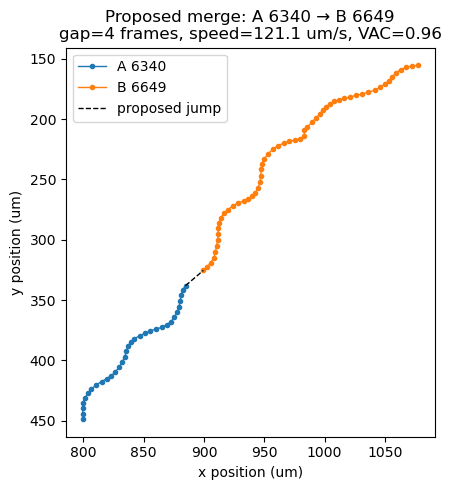

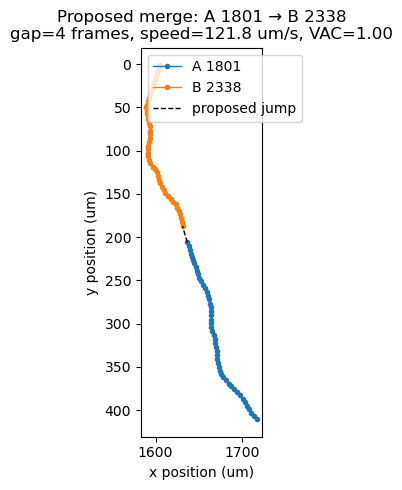

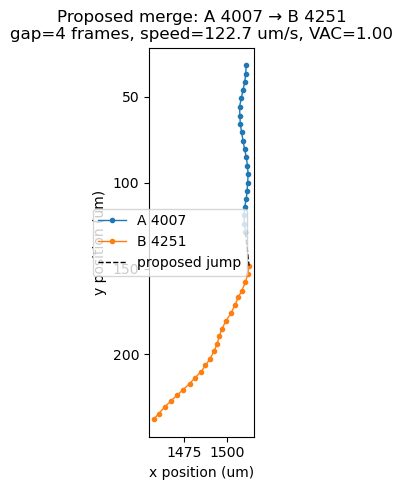

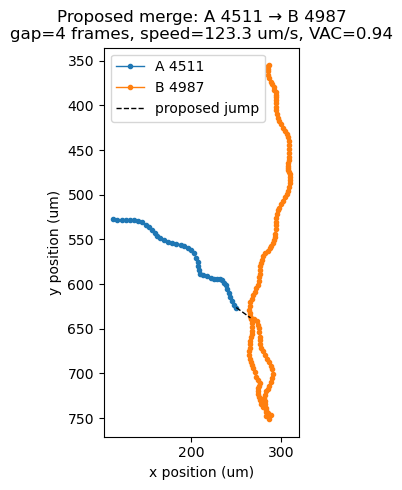

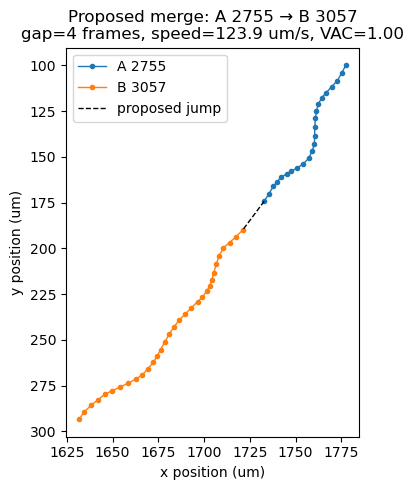

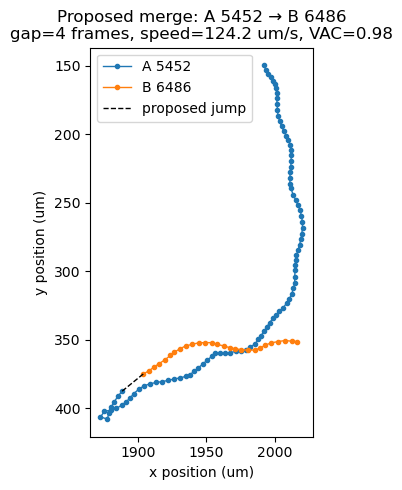

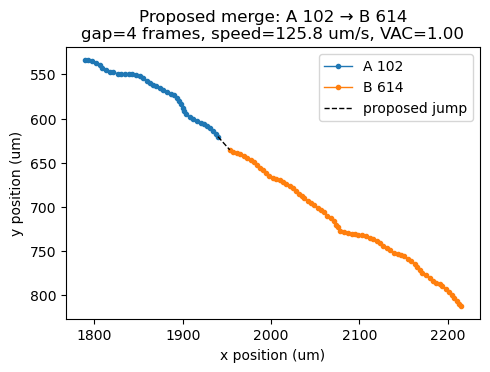

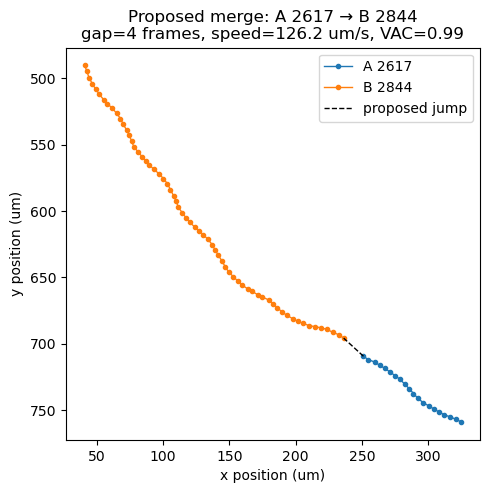

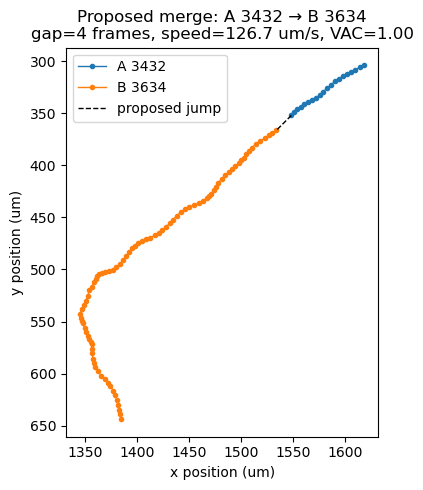

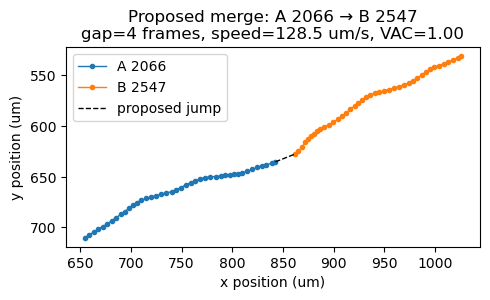

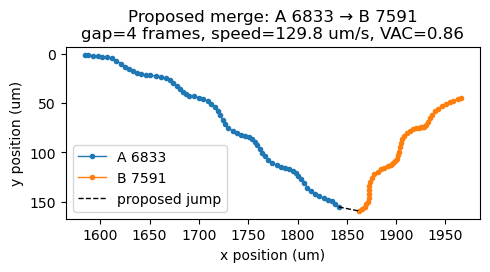

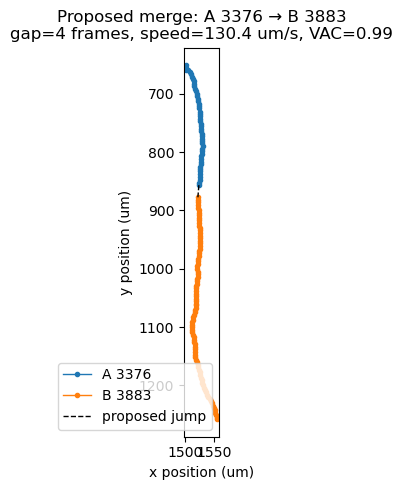

In [29]:
# 14. Visually inspect selected jump links
# Goal: check whether proposed broken-track joins look reasonable before merging.

n_jumps_to_inspect = 12

# Inspect the last selected jumps here.
# You can change tail(...) to head(...) or sample(...) depending on what you want to check.
jump_links_to_plot = selected_jmp_links.tail(n_jumps_to_inspect)

for _, row in jump_links_to_plot.iterrows():

    # Track A is the earlier segment.
    track_a = tracks[
        tracks["track_id"] == row["track_a"]
    ].sort_values("frame")

    # Track B is the later possible continuation.
    track_b = tracks[
        tracks["track_id"] == row["track_b"]
    ].sort_values("frame")

    plt.figure(figsize=(5, 5))

    # Plot both segments separately.
    plt.plot(
        track_a["x_um"],
        track_a["y_um"],
        "-o",
        markersize=3,
        linewidth=1,
        label=f"A {int(row['track_a'])}"
    )

    plt.plot(
        track_b["x_um"],
        track_b["y_um"],
        "-o",
        markersize=3,
        linewidth=1,
        label=f"B {int(row['track_b'])}"
    )

    # Draw the proposed jump from the end of A to the start of B.
    plt.plot(
        [track_a["x_um"].iloc[-1], track_b["x_um"].iloc[0]],
        [track_a["y_um"].iloc[-1], track_b["y_um"].iloc[0]],
        "k--",
        linewidth=1,
        label="proposed jump"
    )

    plt.xlabel("x position (um)")
    plt.ylabel("y position (um)")
    plt.title(
        f"Proposed merge: A {int(row['track_a'])} → B {int(row['track_b'])}\n"
        f"gap={int(row['jmp_frames'])} frames, "
        f"speed={row['speed_um_s']:.1f} um/s, "
        f"VAC={row['jmp_vac']:.2f}"
    )

    plt.gca().set_aspect("equal")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Merging broken tracks
1. Create merge map
2. Fill merge map using selected_jmp_links
3. Apply merge map to create tracks_merged

In [30]:
# 15. Create merge map
# Goal: prepare a dictionary that says which track should become the parent track.

# Each track starts as its own parent.
track_parent = {
    int(track_id): int(track_id)
    for track_id in tracks["track_id"].unique()
}

def find_parent(track_id):
    """
    Find the final parent ID of a track.

    If track 20 is merged into track 10,
    then find_parent(20) returns 10.
    """

    while track_parent[track_id] != track_id:
        track_id = track_parent[track_id]

    return track_id

In [31]:
# 16. Fill merge map using selected jump links
# Goal: tell the notebook which later tracks should merge into earlier tracks.

for _, row in selected_jmp_links.iterrows():

    track_a = int(row["track_a"])  # earlier segment
    track_b = int(row["track_b"])  # later segment

    parent_a = find_parent(track_a)
    parent_b = find_parent(track_b)

    # If they already have the same parent, no action is needed.
    if parent_a == parent_b:
        continue

    # Merge the later segment into the earlier segment.
    track_parent[parent_b] = parent_a

In [32]:
# 17. Apply merge map
# Goal: create the final merged track table.

# Protect the original pre-merge tracks table.
tracks_before_merge = tracks.copy()

# Rebuild tracks_merged while preserving original track IDs.
tracks_merged = tracks_before_merge.copy()

# Store the original track ID before changing it.
tracks_merged["original_track_id"] = tracks_merged["track_id"]

# Replace each track ID with its final parent track ID.
tracks_merged["track_id"] = tracks_merged["track_id"].apply(
    lambda track_id: find_parent(int(track_id))
)

In [159]:
'''# Renumber track IDs after merging.
# This makes the final IDs compact: 0, 1, 2, 3, ...

old_track_ids = sorted(tracks_merged["track_id"].unique())

new_track_id_map = {
    old_id: new_id
    for new_id, old_id in enumerate(old_track_ids)
}

tracks_merged["track_id"] = tracks_merged["track_id"].map(new_track_id_map)'''

'# Renumber track IDs after merging.\n# This makes the final IDs compact: 0, 1, 2, 3, ...\n\nold_track_ids = sorted(tracks_merged["track_id"].unique())\n\nnew_track_id_map = {\n    old_id: new_id\n    for new_id, old_id in enumerate(old_track_ids)\n}\n\ntracks_merged["track_id"] = tracks_merged["track_id"].map(new_track_id_map)'

In [33]:
# 18. Check merge result
# Goal: verify that merging changed track IDs but did not lose detections.

track_lengths_before = tracks_before_merge.groupby("track_id").size()
track_lengths_after = tracks_merged.groupby("track_id").size()

print("Detections before:", len(tracks_before_merge))
print("Detections after:", len(tracks_merged))

print("Tracks before:", tracks_before_merge["track_id"].nunique())
print("Tracks after:", tracks_merged["track_id"].nunique())

print("Rows whose track_id changed:")
print((tracks_merged["track_id"] != tracks_merged["original_track_id"]).sum())

print("\nBefore merging:")
print(track_lengths_before.describe())

print("\nAfter merging:")
print(track_lengths_after.describe())

Detections before: 204182
Detections after: 204182
Tracks before: 8127
Tracks after: 7826
Rows whose track_id changed:
24405

Before merging:
count    8127.000000
mean       25.123908
std        49.404176
min         1.000000
25%         2.000000
50%         5.000000
75%        26.000000
max       768.000000
dtype: float64

After merging:
count    7826.000000
mean       26.090212
std        55.130345
min         1.000000
25%         2.000000
50%         5.000000
75%        22.000000
max       768.000000
dtype: float64


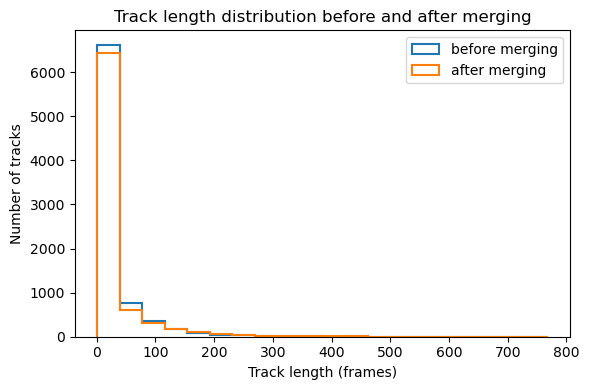

In [34]:
# 19. Compare track length distributions before and after merging
# Goal: check whether merging reduces fragmentation without changing detections.

plt.figure(figsize=(6, 4))

plt.hist(
    track_lengths_before,
    bins=20,
    histtype="step",
    linewidth=1.5,
    label="before merging"
)

plt.hist(
    track_lengths_after,
    bins=20,
    histtype="step",
    linewidth=1.5,
    label="after merging"
)

plt.xlabel("Track length (frames)")
plt.ylabel("Number of tracks")
plt.title("Track length distribution before and after merging")
plt.legend()
plt.tight_layout()
plt.show()

### Merge check

The number of detections is unchanged before and after merging. This means no cell detections were removed or duplicated during the merge step.

The number of tracks decreased from 4832 to 4786, so 46 broken track segments were merged.

The mean track length increased slightly, from 13.26 to 13.39 frames. This is expected because merging combines some short broken segments into longer tracks.

The maximum track length stayed 255 frames, meaning the longest track was already near the full video length before merging.

Overall, this merge step is conservative: it repairs some broken tracks without strongly changing the full dataset.

Number of merged tracks: 7826
Longest merged track length: 768
Shortest track in this plot: 243


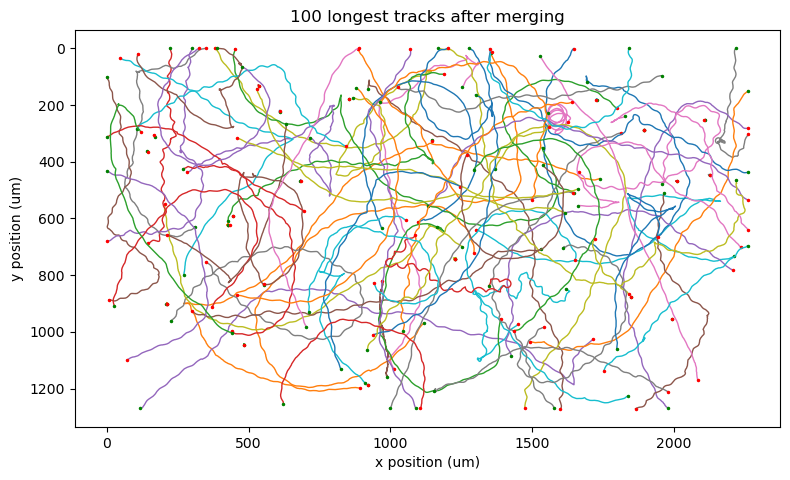

In [35]:
# 20. Plot longest tracks after merging
# Goal: visually inspect whether merged tracks look continuous and reasonable.

n_tracks_to_plot = 100

# Count detections per merged track.
merged_track_lengths = tracks_merged.groupby("track_id").size()

# Select the longest merged tracks.
selected_track_ids = merged_track_lengths.nlargest(n_tracks_to_plot).index

print("Number of merged tracks:", tracks_merged["track_id"].nunique())
print("Longest merged track length:", merged_track_lengths.max())
print("Shortest track in this plot:", merged_track_lengths.loc[selected_track_ids].min())


plt.figure(figsize=(8, 7))

for track_id in selected_track_ids:

    track = tracks_merged[
        tracks_merged["track_id"] == track_id
    ].sort_values("frame")

    # Plot the full merged trajectory.
    plt.plot(
        track["x_um"],
        track["y_um"],
        "-",
        linewidth=1
    )

    # Mark start point in green.
    plt.plot(
        track["x_um"].iloc[0],
        track["y_um"].iloc[0],
        "go",
        markersize=1.5
    )

    # Mark end point in red.
    plt.plot(
        track["x_um"].iloc[-1],
        track["y_um"].iloc[-1],
        "ro",
        markersize=1.5
    )

plt.xlabel("x position (um)")
plt.ylabel("y position (um)")
plt.title(f"{n_tracks_to_plot} longest tracks after merging")

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

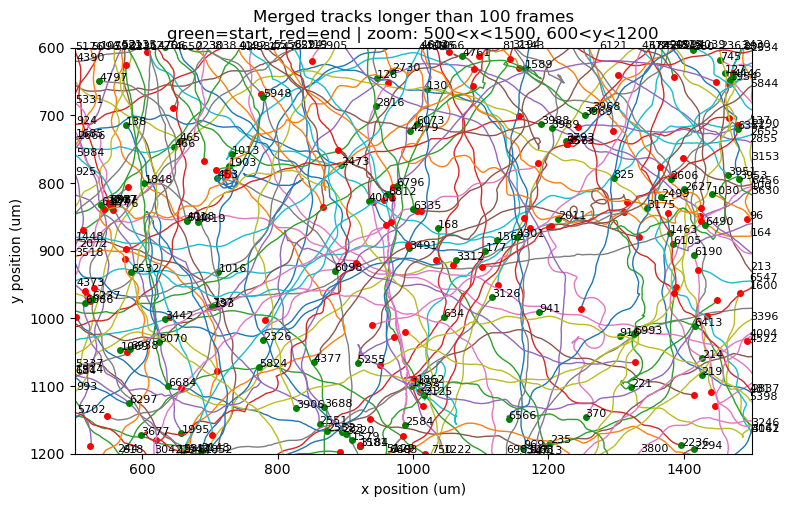

In [36]:
# 21. Plot long merged tracks in a zoom window with track ID labels
# Goal: identify long tracks inside a selected spatial region.


min_track_length = 100

x_min, x_max = 500, 1500
y_min, y_max = 600, 1200
merged_track_lengths = tracks_merged.groupby("track_id").size()

long_track_ids = merged_track_lengths[
    merged_track_lengths >= min_track_length
].index


plt.figure(figsize=(8, 7))

tracks_in_window = []

for track_id in long_track_ids:

    track = tracks_merged[
        tracks_merged["track_id"] == track_id
    ].sort_values("frame")

    # Check whether this track has at least one point inside the zoom window.
    inside_window = (
        (track["x_um"] >= x_min)
        & (track["x_um"] <= x_max)
        & (track["y_um"] >= y_min)
        & (track["y_um"] <= y_max)
    )

    if not inside_window.any():
        continue

    tracks_in_window.append(track_id)

    # Plot full track. Only the zoomed part will be visible because of xlim/ylim.
    plt.plot(
        track["x_um"],
        track["y_um"],
        "-",
        linewidth=1
    )

    # Mark full-track start point in green.
    plt.plot(
        track["x_um"].iloc[0],
        track["y_um"].iloc[0],
        "go",
        markersize=4
    )

    # Mark full-track end point in red.
    plt.plot(
        track["x_um"].iloc[-1],
        track["y_um"].iloc[-1],
        "ro",
        markersize=4
    )

    # Label the track near its first point inside the zoom window.
    label_point = track[inside_window].iloc[0]

    plt.text(
        label_point["x_um"],
        label_point["y_um"],
        str(track_id),
        fontsize=8,
        bbox=dict(facecolor="none", alpha=0.7, edgecolor="none")
    )

plt.xlabel("x position (um)")
plt.ylabel("y position (um)")
plt.title(
    f"Merged tracks longer than {min_track_length} frames\n"
    f"green=start, red=end | zoom: {x_min}<x<{x_max}, {y_min}<y<{y_max}"
)

plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)  # reversed because image y-axis is inverted
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.show()


#print("Track IDs shown in this window:")
#print(tracks_in_window)

<div style="
border-left:6px solid #E67E22;
background-color:#FFF8E8;
padding:10px;
margin:10px 0;
">

<b>Optional manual validation</b>

<ul>
<li>Inspect two candidate tracks and evaluate whether they should be merged.</li>
<li>Tracks that overlap in time should generally <b>not</b> be merged.</li>
<li>For non-overlapping tracks, assess:
    <ul>
        <li>Jump distance</li>
        <li>Linking speed</li>
        <li>VAC (Velocity Alignment Criterion)</li>
    </ul>
</li>
</ul>

</div>

In [164]:
# Optional manual check:

track_id_a = 54
track_id_b = 1561

# Select tracks and sort by time
track_a = tracks_merged[
    tracks_merged["track_id"] == track_id_a
].sort_values("frame")

track_b = tracks_merged[
    tracks_merged["track_id"] == track_id_b
].sort_values("frame")

print("A frames:", track_a["frame"].min(), "to", track_a["frame"].max())
print("B frames:", track_b["frame"].min(), "to", track_b["frame"].max())

# Check whether the two tracks exist in the same frames
overlap_frames = sorted(
    set(track_a["frame"]).intersection(set(track_b["frame"]))
)

print("Number of overlapping frames:", len(overlap_frames))

if len(overlap_frames) > 0:
    # If tracks overlap, measure how far apart they are during overlap
    overlap_distances = []

    for frame in overlap_frames:
        point_a = track_a[
            track_a["frame"] == frame
        ][["x_um", "y_um"]].iloc[0].to_numpy()

        point_b = track_b[
            track_b["frame"] == frame
        ][["x_um", "y_um"]].iloc[0].to_numpy()

        overlap_distances.append({
            "frame": frame,
            "distance_um": np.linalg.norm(point_a - point_b)
        })

    overlap_distances = pd.DataFrame(overlap_distances)

    print("Overlap distance summary:")
    print(overlap_distances["distance_um"].describe())

else:
    # If tracks do not overlap, test whether A can jump to B
    jmp_frames = track_b["frame"].iloc[0] - track_a["frame"].iloc[-1]

    print("A -> B jmp frames:", jmp_frames)

    if jmp_frames <= 0:
        print("A does not end before B starts. Try reversing track_id_a and track_id_b.")

    else:
        p_a_end = track_a[["x_um", "y_um"]].iloc[-1].to_numpy()
        p_b_start = track_b[["x_um", "y_um"]].iloc[0].to_numpy()

        jmp_distance_um = np.linalg.norm(p_b_start - p_a_end)
        jmp_speed_um_s = jmp_distance_um / jmp_frames * fps

        print("A -> B jmp distance um:", jmp_distance_um)
        print("A -> B jmp speed um/s:", jmp_speed_um_s)

        # VAC needs two points at the end of A
        if len(track_a) >= 2:
            p0 = track_a[["x_um", "y_um"]].iloc[-2].to_numpy()
            p1 = track_a[["x_um", "y_um"]].iloc[-1].to_numpy()
            p2 = track_b[["x_um", "y_um"]].iloc[0].to_numpy()

            jmp_vac = calculate_vac(p0, p1, p2)

            print("A -> B jmp VAC:", jmp_vac)
        else:
            print("Track A is too short to calculate jmp VAC.")

A frames: 0 to 240
B frames: 135 to 142
Number of overlapping frames: 8
Overlap distance summary:
count       8.000000
mean     1329.449133
std         2.299619
min      1324.463142
25%      1328.899378
50%      1329.856429
75%      1330.701094
max      1331.953926
Name: distance_um, dtype: float64


In [114]:
# Check whether original track IDs were preserved during merging

print("tracks columns:")
print(tracks.columns.tolist())

print("tracks_merged columns:")
print(tracks_merged.columns.tolist())

if "original_track_id" in tracks_merged.columns:
    print("Good: original_track_id exists.")
    print("Manual inspection can use original IDs.")

    print("Number of original track IDs:")
    print(tracks_merged["original_track_id"].nunique())

    print("Number of merged track IDs:")
    print(tracks_merged["track_id"].nunique())

else:
    print("original_track_id is missing.")
    print("Renumbering may have overwritten the old IDs.")

tracks columns:
['frame', 'label', 'y_px', 'x_px', 'y_um', 'x_um', 'area_px', 'area_um2', 'mean_intensity', 'threshold_value', 'eccentricity_value', 'orientation_value', 'axis_major_length', 'axis_minor_length', 'track_id']
tracks_merged columns:
['frame', 'label', 'y_px', 'x_px', 'y_um', 'x_um', 'area_px', 'area_um2', 'mean_intensity', 'threshold_value', 'eccentricity_value', 'orientation_value', 'axis_major_length', 'axis_minor_length', 'track_id', 'original_track_id']
Good: original_track_id exists.
Manual inspection can use original IDs.
Number of original track IDs:
3214
Number of merged track IDs:
3160


In [101]:
print("Selected jump links:", len(selected_jmp_links))

print("Rows before:", len(tracks))
print("Rows after:", len(tracks_merged))

print("Tracks before:", tracks["track_id"].nunique())
print("Tracks after:", tracks_merged["track_id"].nunique())

print("Rows whose track_id changed:")
print((tracks_merged["track_id"] != tracks_merged["original_track_id"]).sum())

Selected jump links: 54
Rows before: 66134
Rows after: 66134
Tracks before: 3214
Tracks after: 3160
Rows whose track_id changed:
3466


## overlay tracks_merged to the video

In [43]:
tracks_to_show = tracks_merged[
    tracks_merged["track_id"].isin(long_track_ids)
].copy()

In [44]:
selected_ids = [131, 1795, 658, 792]
tracks_to_show = tracks_merged[
    tracks_merged["track_id"].isin(selected_ids)
].copy()

In [45]:
# 22. Overlay selected merged tracks on the original video
# Goal: visually validate whether tracks follow the actual cells.

import cv2
import numpy as np
from pathlib import Path

# -----------------------------
# Video and output settings
# -----------------------------

video_path = Path("../UN_test2.mp4")
output_path = Path("tracks_merged_overlay_validation.mp4")

frame_start = 0
frame_end = 250

# Choose which tracks to show.
# Option 1: show long tracks
min_track_length = 100
merged_track_lengths = tracks_merged.groupby("track_id").size()
selected_ids = merged_track_lengths[
    merged_track_lengths >= min_track_length
].index.tolist()

# Option 2: manually inspect specific tracks
# selected_ids = [131, 1795, 658, 792]

tracks_to_show = tracks_merged[
    tracks_merged["track_id"].isin(selected_ids)
].copy()

print("Number of selected tracks:", len(selected_ids))
print("Number of selected detections:", len(tracks_to_show))


# -----------------------------
# Open input video
# -----------------------------

cap = cv2.VideoCapture(str(video_path))

fps_video = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    str(output_path),
    fourcc,
    fps_video,
    (width, height)
)


# -----------------------------
# Prepare colors for track IDs
# -----------------------------

rng = np.random.default_rng(0)

track_colors = {
    int(track_id): tuple(
        int(v) for v in rng.integers(50, 255, size=3)
    )
    for track_id in selected_ids
}


# -----------------------------
# Draw frame-by-frame overlay
# -----------------------------

for frame_number in range(frame_start, frame_end + 1):

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame = cap.read()

    if not ok:
        break

    # Draw trajectories up to the current frame.
    frame_tracks = tracks_to_show[
        tracks_to_show["frame"] <= frame_number
    ]

    for track_id, track in frame_tracks.groupby("track_id"):

        track = track.sort_values("frame")

        # Only draw the trail if this track has appeared.
        if len(track) == 0:
            continue

        color = track_colors[int(track_id)]

        points = track[["x_px", "y_px"]].to_numpy().astype(int)

        # Draw trail.
        if len(points) >= 2:
            cv2.polylines(
                frame,
                [points],
                isClosed=False,
                color=color,
                thickness=1
            )

        # Draw current/latest point up to this frame.
        x, y = points[-1]
        cv2.circle(frame, (x, y), 1, color, -1)

        # Draw track ID near the current point.
        cv2.putText(
            frame,
            str(int(track_id)),
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            color,
            1,
            cv2.LINE_AA
        )

    # Draw frame number.
    cv2.putText(
        frame,
        f"frame {frame_number}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    writer.write(frame)


cap.release()
writer.release()

print("Saved overlay video to:", output_path)

Number of selected tracks: 579
Number of selected detections: 106973
Saved overlay video to: tracks_merged_overlay_validation.mp4


# visible cell → not in detections table

# Manual merging

In [46]:
manual_merge_pairs = [
    (213, 1954),
    (138, 2144),
    (464, 1950),
    (54, 1291),
    (360, 1229),
    (128, 1666),
    (183, 1381),
]

manual_corrections = pd.DataFrame([
    {
        "action": "merge",
        "track_a": track_a,
        "track_b": track_b,
        "reason": "same visible cell, checked on video"
    }
    for track_a, track_b in manual_merge_pairs
])

manual_corrections

,action,track_a,track_b,reason
0,merge,213,1954,"same visible cell, checked on video"
1,merge,138,2144,"same visible cell, checked on video"
2,merge,464,1950,"same visible cell, checked on video"
3,merge,54,1291,"same visible cell, checked on video"
4,merge,360,1229,"same visible cell, checked on video"
5,merge,128,1666,"same visible cell, checked on video"
6,merge,183,1381,"same visible cell, checked on video"


In [47]:
manual_track_parent = {
    int(track_id): int(track_id)
    for track_id in tracks_merged["track_id"].unique()
}

def manual_find_parent(track_id):
    while manual_track_parent[track_id] != track_id:
        track_id = manual_track_parent[track_id]
    return track_id

for _, row in manual_corrections.iterrows():
    if row["action"] == "merge":
        track_a = int(row["track_a"])
        track_b = int(row["track_b"])

        parent_a = manual_find_parent(track_a)
        parent_b = manual_find_parent(track_b)

        manual_track_parent[parent_b] = parent_a

tracks_corrected = tracks_merged.copy()
tracks_corrected["track_id_before_manual"] = tracks_corrected["track_id"]
tracks_corrected["track_id"] = tracks_corrected["track_id"].apply(
    lambda x: manual_find_parent(int(x))
)

In [49]:
# Check manual correction result

print("Tracks before manual correction:", tracks_merged["track_id"].nunique())
print("Tracks after manual correction:", tracks_corrected["track_id"].nunique())

print("Rows changed by manual correction:")
print(
    (tracks_corrected["track_id"] != tracks_corrected["track_id_before_manual"]).sum()
)

Tracks before manual correction: 7826
Tracks after manual correction: 7819
Rows changed by manual correction:
836


In [50]:
# Overlay corrected tracks on the original video
# Goal: visually validate the human-corrected final tracks.

import cv2
import numpy as np
from pathlib import Path

# -----------------------------
# Video and output settings
# -----------------------------

video_path = Path("../UN_test2.mp4")
output_path = Path("tracks_corrected.mp4")

frame_start = 0
frame_end = 250


# -----------------------------
# Choose tracks to show
# -----------------------------

# Option 1: show long corrected tracks
min_track_length = 100

corrected_track_lengths = tracks_corrected.groupby("track_id").size()

selected_ids = corrected_track_lengths[
    corrected_track_lengths >= min_track_length
].index.tolist()

# Option 2: manually inspect specific corrected tracks
# selected_ids = [82, 131, 1795, 2030]

tracks_to_show = tracks_corrected[
    tracks_corrected["track_id"].isin(selected_ids)
].copy()

print("Number of selected tracks:", len(selected_ids))
print("Number of selected detections:", len(tracks_to_show))


# -----------------------------
# Open input video
# -----------------------------

cap = cv2.VideoCapture(str(video_path))

fps_video = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(output_path),
    fourcc,
    fps_video,
    (width, height)
)


# -----------------------------
# Prepare colors for track IDs
# -----------------------------

rng = np.random.default_rng(0)

track_colors = {
    int(track_id): tuple(
        int(v) for v in rng.integers(50, 255, size=3)
    )
    for track_id in selected_ids
}


# -----------------------------
# Draw frame-by-frame overlay
# -----------------------------

for frame_number in range(frame_start, frame_end + 1):

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame = cap.read()

    if not ok:
        break

    # Use only detections up to the current frame to draw trails.
    frame_tracks = tracks_to_show[
        tracks_to_show["frame"] <= frame_number
    ]

    for track_id, track in frame_tracks.groupby("track_id"):

        track = track.sort_values("frame")

        if len(track) == 0:
            continue

        color = track_colors[int(track_id)]

        points = track[["x_px", "y_px"]].to_numpy().astype(int)

        # Draw track trail.
        if len(points) >= 2:
            cv2.polylines(
                frame,
                [points],
                isClosed=False,
                color=color,
                thickness=1
            )

        # Draw current/latest detected point.
        x, y = points[-1]
        cv2.circle(frame, (x, y), 3, color, -1)

        # Draw corrected track ID.
        cv2.putText(
            frame,
            str(int(track_id)),
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            color,
            1,
            cv2.LINE_AA
        )

    # Draw frame number.
    cv2.putText(
        frame,
        f"frame {frame_number}",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    writer.write(frame)


cap.release()
writer.release()

print("Saved corrected overlay video to:", output_path)

Number of selected tracks: 573
Number of selected detections: 106974
Saved corrected overlay video to: tracks_corrected.mp4


In [51]:
tracks_corrected.to_csv("tracks_corrected_30s.csv", index=False)
manual_corrections.to_csv("manual_corrections_30s.csv", index=False)